# SmartBasket AI
## Intelligent Shopping & Market Basket Recommendation System

### Notebook 03 — Exploratory Data Analysis (EDA)

**Dataset:** Instacart Online Grocery Basket Dataset

---

### Objective

The objective of this notebook is to explore customer shopping behavior,
product popularity, order patterns, reorder behavior, and grocery
purchasing trends in the Instacart dataset.

### Analysis Areas

1. Dataset overview
2. Product analysis
3. Customer analysis
4. Order behavior
5. Shopping time analysis
6. Reorder behavior
7. Department analysis
8. Product popularity
9. Basket-level analysis
10. Key business insights

# step 1- Import Libraries

In [46]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# Step2- Load Manageable Data

In [47]:
RAW_PATH = "../data/raw/"

aisles = pd.read_csv(
    RAW_PATH + "aisles.csv"
)

departments = pd.read_csv(
    RAW_PATH + "departments.csv"
)

products = pd.read_csv(
    RAW_PATH + "products.csv"
)

orders = pd.read_csv(
    RAW_PATH + "orders.csv"
)

print("Datasets loaded successfully.")

Datasets loaded successfully.


# Step3- Dataset Overview

In [48]:
print("Aisles Shape:", aisles.shape)
print("Departments Shape:", departments.shape)
print("Products Shape:", products.shape)
print("Orders Shape:", orders.shape)

Aisles Shape: (134, 2)
Departments Shape: (21, 2)
Products Shape: (49688, 4)
Orders Shape: (3421083, 7)


# step4- Orders Overview

In [49]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


# Step5 - Customer Statistics

In [50]:
total_customers = orders["user_id"].nunique()
total_orders = orders["order_id"].nunique()

print(f"Total Customers: {total_customers:,}")
print(f"Total Orders: {total_orders:,}")

Total Customers: 206,209
Total Orders: 3,421,083


# step6- Orders per Customer

In [51]:
total_customers = orders["user_id"].nunique()
total_orders = orders["order_id"].nunique()

print(f"Total Customers: {total_customers:,}")
print(f"Total Orders: {total_orders:,}")

Total Customers: 206,209
Total Orders: 3,421,083


# Step 7 - Orders per Customer

In [52]:
orders_per_customer = (
    orders.groupby("user_id")["order_id"]
    .count()
)

orders_per_customer.describe()

count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: order_id, dtype: float64

# Step 8 - Orders per Customer Distribution

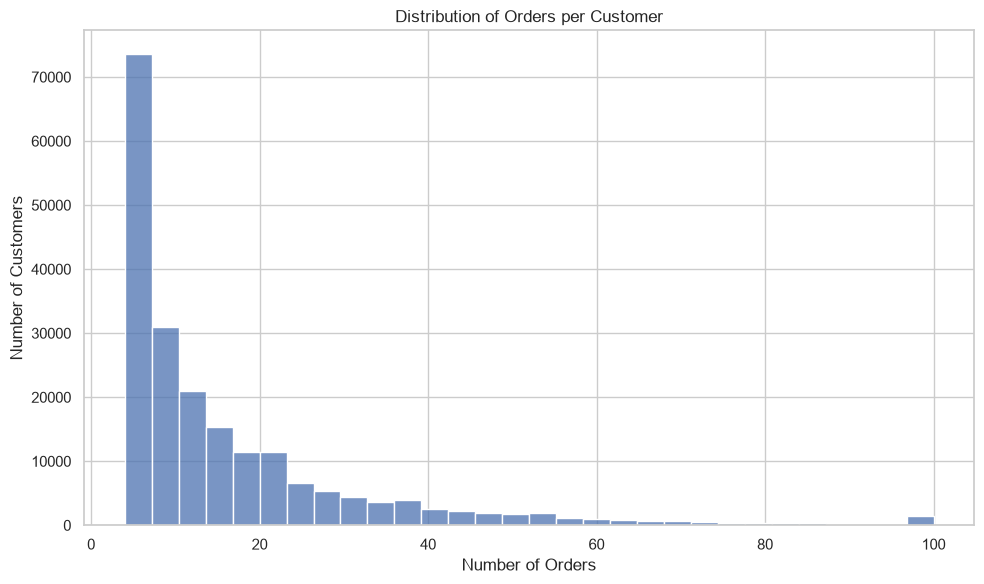

In [53]:
plt.figure(figsize=(10, 6))

sns.histplot(
    orders_per_customer,
    bins=30
)

plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

# Step 9 - Top Customers by Number of Orders

In [54]:
top_customers = (
    orders_per_customer
    .sort_values(ascending=False)
    .head(10)
)

top_customers

user_id
75124     100
173431    100
127158    100
96192     100
173073    100
172966    100
18998     100
62866     100
62890     100
96497     100
Name: order_id, dtype: int64

# ORDER TIMING ANALYSIS
## Step 10 — Orders by Hour

In [55]:
orders_by_hour = (
    orders["order_hour_of_day"]
    .value_counts()
    .sort_index()
)

orders_by_hour

order_hour_of_day
0      22758
1      12398
2       7539
3       5474
4       5527
5       9569
6      30529
7      91868
8     178201
9     257812
10    288418
11    284728
12    272841
13    277999
14    283042
15    283639
16    272553
17    228795
18    182912
19    140569
20    104292
21     78109
22     61468
23     40043
Name: count, dtype: int64

# Step 11 — Hourly Order Visualization

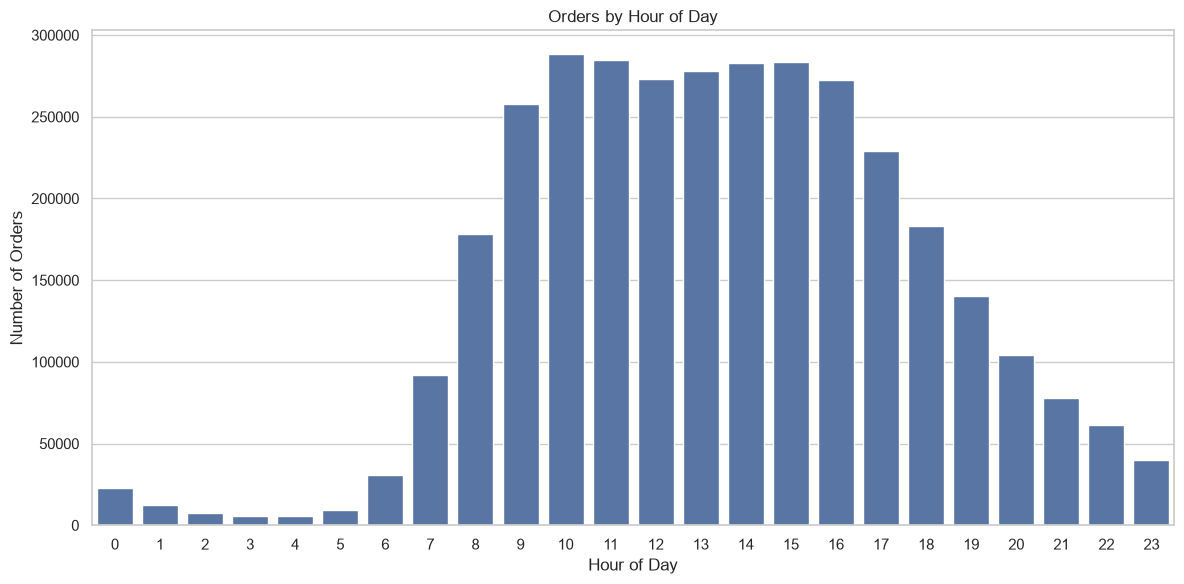

In [56]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=orders_by_hour.index,
    y=orders_by_hour.values
)

plt.title("Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

# Step 12 — Orders by Day of Week

### Instacart

In [57]:
day_names = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday"
}

orders_by_day = (
    orders["order_dow"]
    .value_counts()
    .sort_index()
)

orders_by_day.index = [
    day_names[i]
    for i in orders_by_day.index
]

orders_by_day

Sunday       600905
Monday       587478
Tuesday      467260
Wednesday    436972
Thursday     426339
Friday       453368
Saturday     448761
Name: count, dtype: int64

# Step 13 — Day-wise Visualization

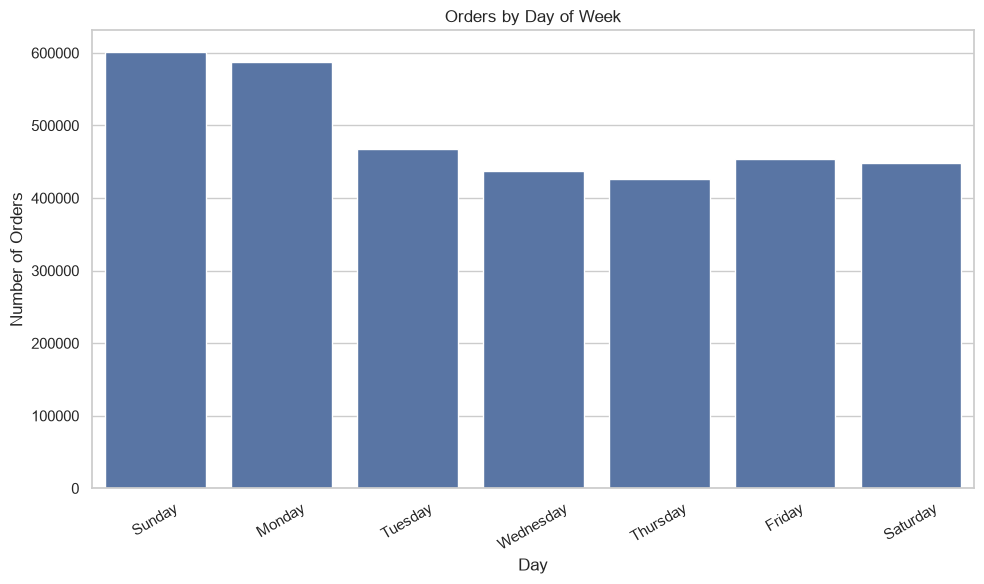

In [58]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=orders_by_day.index,
    y=orders_by_day.values
)

plt.title("Orders by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Orders")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# REORDER ANALYSIS

# step 14 — Reorder Statistics

In [59]:
prior_path = "../data/raw/order_products__prior.csv"

chunk_size = 500_000

reordered_count = 0
not_reordered_count = 0

for chunk in pd.read_csv(
    prior_path,
    chunksize=chunk_size,
    usecols=["reordered"],
    dtype={"reordered": "int8"}
):
    
    counts = chunk["reordered"].value_counts()
    
    reordered_count += counts.get(1, 0)
    not_reordered_count += counts.get(0, 0)

print(f"Reordered: {reordered_count:,}")
print(f"Not Reordered: {not_reordered_count:,}")

Reordered: 19,126,536
Not Reordered: 13,307,953


# Step 15 — Reorder Percentage

In [60]:
total_product_orders = (
    reordered_count +
    not_reordered_count
)

reordered_percentage = (
    reordered_count /
    total_product_orders
) * 100

not_reordered_percentage = (
    not_reordered_count /
    total_product_orders
) * 100

print(f"Reordered: {reordered_percentage:.2f}%")
print(f"Not Reordered: {not_reordered_percentage:.2f}%")

Reordered: 58.97%
Not Reordered: 41.03%


# Step 16 — Reorder Visualization

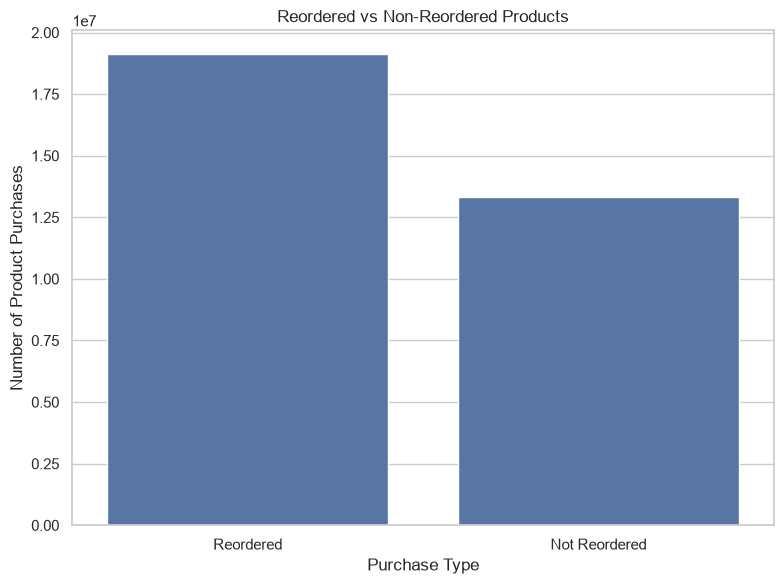

In [61]:
reorder_data = pd.Series({
    "Reordered": reordered_count,
    "Not Reordered": not_reordered_count
})

plt.figure(figsize=(8, 6))

sns.barplot(
    x=reorder_data.index,
    y=reorder_data.values
)

plt.title("Reordered vs Non-Reordered Products")
plt.xlabel("Purchase Type")
plt.ylabel("Number of Product Purchases")

plt.tight_layout()
plt.show()

# PRODUCT ANALYSIS
# Step 17 — Product Information

In [62]:
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


# Step 18 — Products per Department

In [63]:
products_per_department = (
    products.groupby("department_id")["product_id"]
    .count()
    .sort_values(ascending=False)
)

products_per_department.head(10)

department_id
11    6563
19    6264
13    5371
7     4365
1     4007
16    3449
17    3085
15    2092
9     1858
4     1684
Name: product_id, dtype: int64

# Step 19 — Department Names

In [64]:
products_with_department = products.merge(
    departments,
    on="department_id",
    how="left"
)

products_with_department.head()

,product_id,product_name,aisle_id,department_id,department
0,1,Chocolate Sandwich Cookies,61,19,snacks
1,2,All-Seasons Salt,104,13,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen
4,5,Green Chile Anytime Sauce,5,13,pantry


# Step 20 — Products by Department

In [65]:
department_product_count = (
    products_with_department
    .groupby("department")
    ["product_id"]
    .count()
    .sort_values(ascending=False)
)

department_product_count

department
personal care      6563
snacks             6264
pantry             5371
beverages          4365
frozen             4007
dairy eggs         3449
household          3085
canned goods       2092
dry goods pasta    1858
produce            1684
bakery             1516
deli               1322
missing            1258
international      1139
breakfast          1115
babies             1081
alcohol            1054
pets                972
meat seafood        907
other               548
bulk                 38
Name: product_id, dtype: int64

# Step 21 — Department Visualization

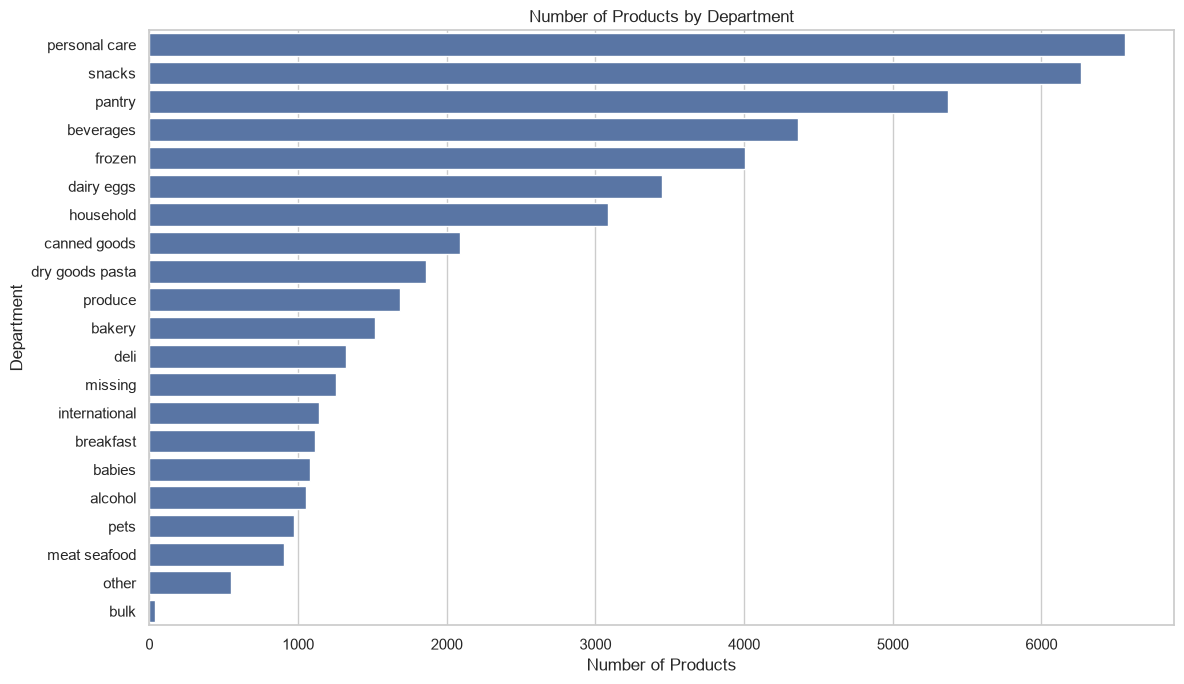

In [66]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=department_product_count.values,
    y=department_product_count.index
)

plt.title("Number of Products by Department")
plt.xlabel("Number of Products")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

# PRODUCT PURCHASE FREQUENCY

# Step 22

In [67]:
prior_path = "../data/raw/order_products__prior.csv"

chunk_size = 500_000

product_frequency = {}

for chunk in pd.read_csv(
    prior_path,
    chunksize=chunk_size,
    usecols=["product_id"],
    dtype={
        "product_id": "int32"
    }
):
    
    counts = chunk["product_id"].value_counts()
    
    for product_id, count in counts.items():
        product_frequency[product_id] = (
            product_frequency.get(product_id, 0) + count
        )

print(
    "Unique products found:",
    len(product_frequency)
)

Unique products found: 49677


In [68]:
product_frequency = pd.DataFrame(
    product_frequency.items(),
    columns=[
        "product_id",
        "purchase_count"
    ]
)

product_frequency = product_frequency.sort_values(
    "purchase_count",
    ascending=False
)

print(product_frequency.shape)

product_frequency.head()

(49677, 2)


,product_id,purchase_count
0,24852,472565
1,13176,379450
2,21137,264683
3,21903,241921
4,47209,213584


In [69]:
# add the product name 

product_frequency = product_frequency.merge(
    products[
        [
            "product_id",
            "product_name"
        ]
    ],
    on="product_id",
    how="left"
)

product_frequency.head(20)

,product_id,purchase_count,product_name
0,24852,472565,Banana
1,13176,379450,Bag of Organic Bananas
2,21137,264683,Organic Strawberries
3,21903,241921,Organic Baby Spinach
4,47209,213584,Organic Hass Avocado
5,47766,176815,Organic Avocado
6,47626,152657,Large Lemon
7,16797,142951,Strawberries
8,26209,140627,Limes
9,27845,137905,Organic Whole Milk


# step 23 — Top 20 Products

In [70]:
top_products = (
    product_frequency
    .sort_values(
        "purchase_count",
        ascending=False
    )
    .head(20)
)

display(
    top_products[
        ["product_name", "purchase_count"]
    ]
)

,product_name,purchase_count
0,Banana,472565
1,Bag of Organic Bananas,379450
2,Organic Strawberries,264683
3,Organic Baby Spinach,241921
4,Organic Hass Avocado,213584
5,Organic Avocado,176815
6,Large Lemon,152657
7,Strawberries,142951
8,Limes,140627
9,Organic Whole Milk,137905


# Step 24 — Top 20 Products Chart

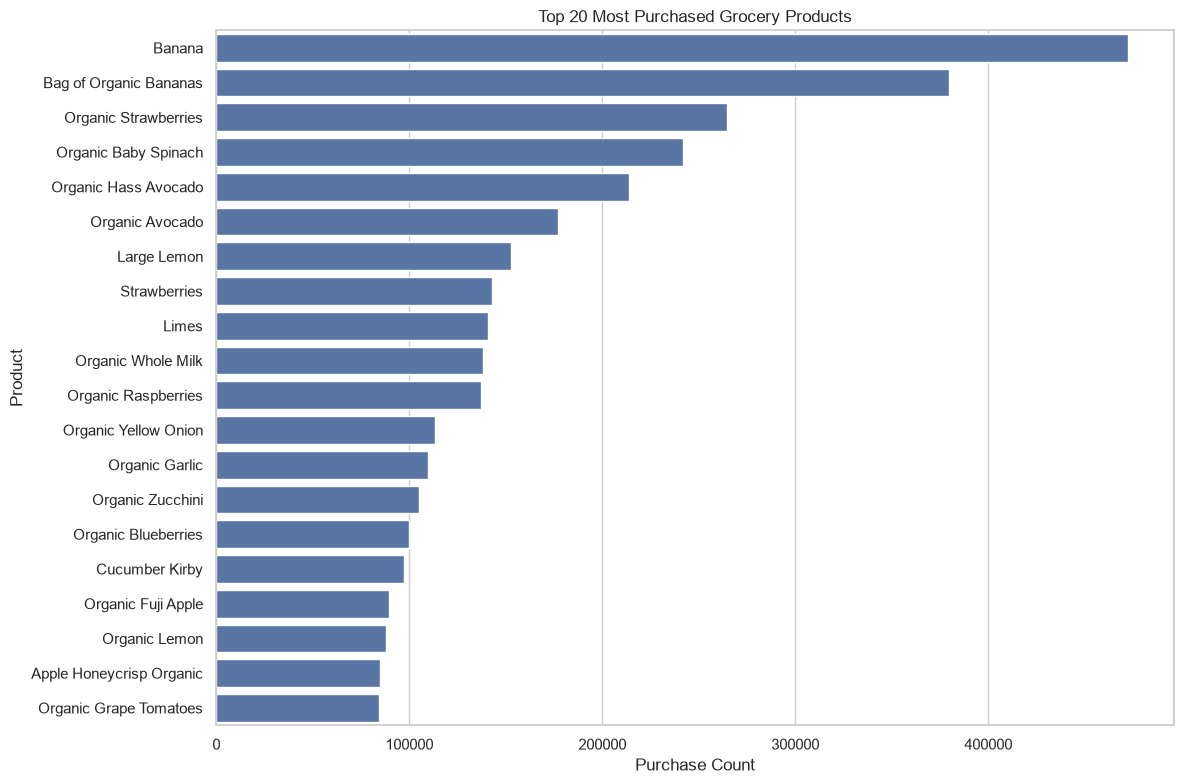

In [71]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_products,
    x="purchase_count",
    y="product_name"
)

plt.title("Top 20 Most Purchased Grocery Products")
plt.xlabel("Purchase Count")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

# TOP PRODUCT

# Step 25 - top product

In [72]:
most_purchased_product = (
    product_frequency
    .sort_values(
        "purchase_count",
        ascending=False
    )
    .iloc[0]
)

print(
    "Most Purchased Product:",
    most_purchased_product["product_name"]
)

print(
    "Purchase Count:",
    f"{most_purchased_product['purchase_count']:,}"
)

Most Purchased Product: Banana
Purchase Count: 472,565


# DEPARTMENT PURCHASE ANALYSIS

# Step 26- department_product_count

In [73]:
frequency_with_department = product_frequency.merge(
    products[[
        "product_id",
        "department_id"
    ]],
    on="product_id",
    how="left"
)

frequency_with_department = frequency_with_department.merge(
    departments,
    on="department_id",
    how="left"
)

frequency_with_department.head()

,product_id,purchase_count,product_name,department_id,department
0,24852,472565,Banana,4,produce
1,13176,379450,Bag of Organic Bananas,4,produce
2,21137,264683,Organic Strawberries,4,produce
3,21903,241921,Organic Baby Spinach,4,produce
4,47209,213584,Organic Hass Avocado,4,produce


# Step 27 — Purchases by Department

In [74]:
department_purchase_frequency = (
    frequency_with_department
    .groupby("department")["purchase_count"]
    .sum()
    .sort_values(ascending=False)
)

department_purchase_frequency

department
produce            9479291
dairy eggs         5414016
snacks             2887550
beverages          2690129
frozen             2236432
pantry             1875577
bakery             1176787
canned goods       1068058
deli               1051249
dry goods pasta     866627
household           738666
breakfast           709569
meat seafood        708931
personal care       447123
babies              423802
international       269253
alcohol             153696
pets                 97724
missing              69145
other                36291
bulk                 34573
Name: purchase_count, dtype: int64

# Step 28 — Visualization

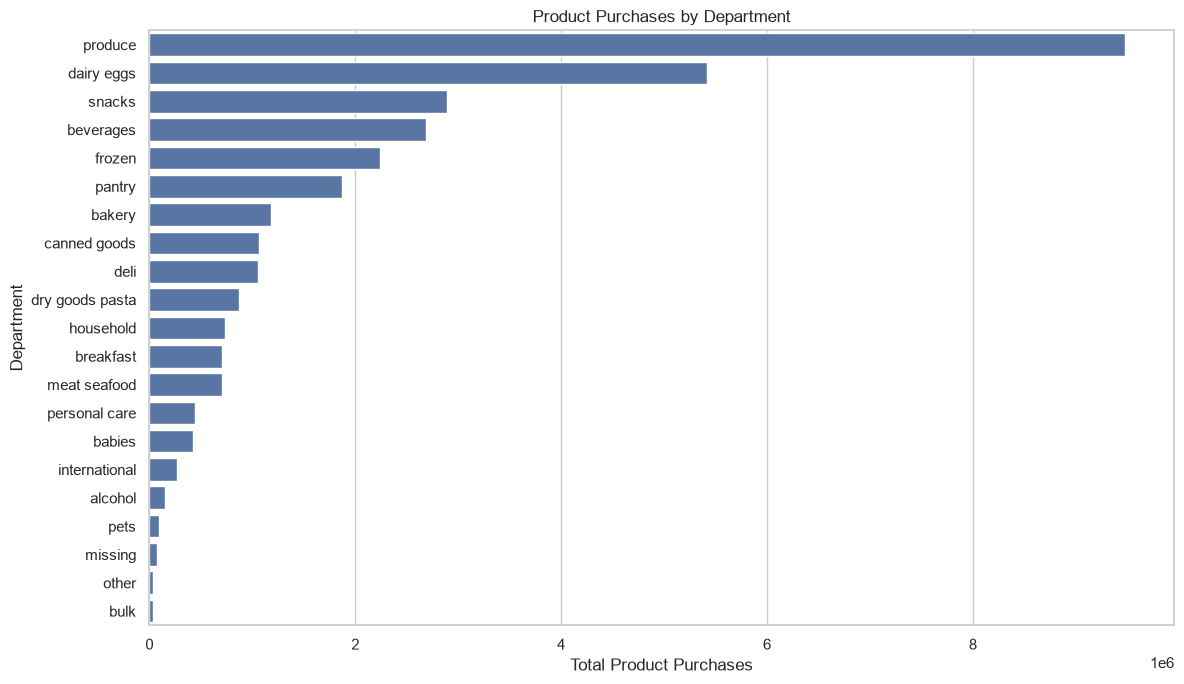

In [75]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=department_purchase_frequency.values,
    y=department_purchase_frequency.index
)

plt.title("Product Purchases by Department")
plt.xlabel("Total Product Purchases")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

# ORDER SIZE ANALYSIS

# Step 29 - Load the large dataset 

In [76]:
order_size = {}

for chunk in pd.read_csv(
    prior_path,
    chunksize=chunk_size,
    usecols=["order_id"],
    dtype={"order_id": "int32"}
):
    
    counts = chunk["order_id"].value_counts()
    
    for order_id, count in counts.items():
        order_size[order_id] = (
            order_size.get(order_id, 0) + count
        )

print(
    "Orders processed:",
    len(order_size)
)

Orders processed: 3214874


# step 30 — Basket Size Statistics

In [77]:
basket_sizes = pd.Series(
    order_size,
    name="basket_size"
)

basket_sizes.describe()

count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
Name: basket_size, dtype: float64

# Step 31 — Basket Size Distribution

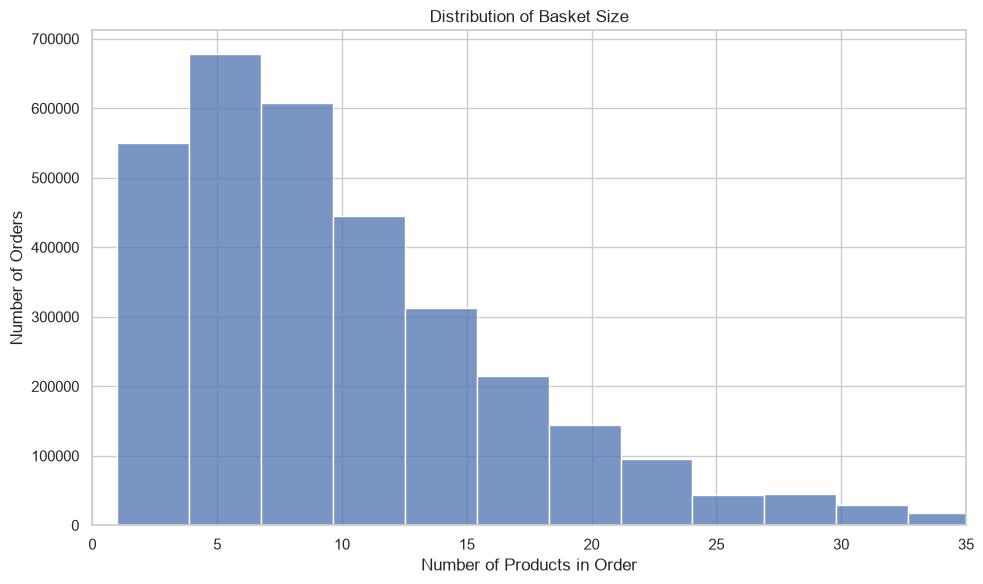

In [78]:
plt.figure(figsize=(10, 6))

sns.histplot(
    basket_sizes,
    bins=50
)

plt.title("Distribution of Basket Size")
plt.xlabel("Number of Products in Order")
plt.ylabel("Number of Orders")

plt.xlim(0, basket_sizes.quantile(0.99))

plt.tight_layout()
plt.show()

# KEY EDA INSIGHTS

Based on the exploratory analysis, the following observations were made:

1. The Instacart dataset contains a large number of customers and
   grocery orders, making it suitable for large-scale recommendation
   analysis.

2. Order activity varies across different hours of the day, indicating
   identifiable shopping-time patterns.

3. Order frequency differs across days of the week, showing that grocery
   shopping behavior is not uniformly distributed.

4. A significant proportion of products are reordered, indicating strong
   repeat-purchase behavior among customers.

5. Product popularity is highly uneven, with a relatively small group
   of products accounting for a large number of purchases.

6. Grocery departments differ substantially in terms of the number of
   available products and purchase frequency.

7. Basket sizes vary across orders, providing useful information for
   understanding customer shopping behavior.

8. Product purchase frequency can be combined with association rules to
   improve recommendation ranking.

9. Reorder behavior can later be incorporated into the personalized
   recommendation component of SmartBasket AI.

10. The findings provide the foundation for Market Basket Analysis using
    frequent itemset mining and association rules.